In [99]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import ConvNeXt_Tiny_Weights, convnext_tiny
import numpy as np
from xgboost import XGBClassifier
import os
import pandas as pd
from glob import glob
import rasterio as rio
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import compute_sample_weight
from src.mslandcover.models import HRNetSegmentationModel
from src.mslandcover.config import LEGEND_CLASSES, LEGEND_COLORS_HEX, HRNET_W18_CONFIG

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
target_paths = glob('data/png_images/batch_0/target/*.tif')
input_paths = [x.replace('target', 'input_tif') for x in target_paths]

img_paths_df = pd.DataFrame({'input': input_paths, 'target': target_paths})
img_paths_df['X'] = img_paths_df['input'].apply(lambda x: rio.open(x).read())
img_paths_df['y'] = img_paths_df['target'].apply(lambda x: rio.open(x).read())
print(f'Total number of images: {len(img_paths_df)}')

dataset_mean = torch.load('./weights/pretrain_mean.pth', weights_only=True).numpy()
dataset_std = torch.load('./weights/pretrain_std.pth', weights_only=True).numpy()

img_paths_df['X_norm'] = img_paths_df['X'].apply(lambda x: ((x.transpose(1, 2, 0) - dataset_mean) / dataset_std).transpose(2, 0, 1))

# add hand-crafted features
def caculate_ndvi(X):
    # nir band is 0
    # red band is 1
    X = X.astype(np.float32)
    return (X[0] - X[1]) / (X[0] + X[1])

def caculate_ndwi(X):
    # nir band is 0
    # green band is 2
    X = X.astype(np.float32)
    return (X[2] - X[0]) / (X[2] + X[0])

def caclulate_gndvi(X):
    # nir band is 0
    # green band is 2
    X = X.astype(np.float32)
    return (X[0] - X[2]) / (X[0] + X[2])

img_paths_df['ndvi'] = img_paths_df['X_norm'].apply(caculate_ndvi)
img_paths_df['ndwi'] = img_paths_df['X_norm'].apply(caculate_ndwi)
img_paths_df['gndvi'] = img_paths_df['X_norm'].apply(caclulate_gndvi)

Total number of images: 90


In [3]:
class ConvNext_Tiny_FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1).features
        
    def forward(self, x):
        feature_maps = []
        for i, block in enumerate(self.feature_extractor):
            x = block(x)
            if (i + 1) % 2 == 0: # only use every 2nd block
                feature_maps.append(F.interpolate(x, size=(64, 64), mode='bilinear', align_corners=True))
        return torch.concatenate(feature_maps, dim=1)

def get_device() -> torch.device:
    
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    else:
        return torch.device('cpu')

device = get_device()
batch_size = 4
n_deep_features = {}

for weights in ['imagenet', 'hsv_simclr']:
# for weights in ['convnext_tiny_inet']:
    
    z_list = []
    if weights == 'imagenet':
        model = HRNetSegmentationModel(HRNET_W18_CONFIG, img_decoder_head=False, aux_simclr_head=False).eval()
        model.load_encoder_weights(torch.load('weights/hrnet_w18/imagenet.pth', weights_only=True, map_location='cpu'))
        model = model.encoder # only use the encoder for HRNet
    elif weights == 'hsv_simclr':
        model = HRNetSegmentationModel(HRNET_W18_CONFIG, img_decoder_head=False, aux_simclr_head=False).eval()
        model.load_state_dict(torch.load('weights/hrnet_w18/hsv_simclr_old.pth', weights_only=True, map_location='cpu'), strict=False)
        model = model.encoder
    else:
        model = ConvNext_Tiny_FeatureExtractor().eval()
    model = model.to(device)
    
    for i in range(0, len(img_paths_df), batch_size):
        X_batch = torch.from_numpy(np.stack(img_paths_df['X_norm'].values[i:i+batch_size])).to(device).to(torch.float32)
        with torch.no_grad():
            z_batch = model(X_batch)
        z_batch = F.interpolate(z_batch, size=(256, 256), mode='bilinear', align_corners=True)
        z_batch = z_batch.detach().to('cpu').numpy()
        z_list.extend(list(z_batch))
    
    img_paths_df[f'z_{weights}'] = z_list
    n_deep_features[weights] = z_list[0].shape[0]
    print(f'Number of deep features per pixel for {weights}: {n_deep_features[weights]}')

Number of deep features per pixel for imagenet: 270
Number of deep features per pixel for hsv_simclr: 270


In [5]:
# append the hand-crafted features to the model output
for weights in ['imagenet', 'hsv_simclr']:
# for weights in ['imagenet', 'hsv_simclr', 'convnext_tiny_inet']:
# for weights in ['convnext_tiny_inet']:
    deep_features = np.stack(img_paths_df[f'z_{weights}'].values)

    aggregated_features = np.concatenate([
        deep_features, 
        np.stack(img_paths_df['ndvi'].values)[:, None], 
        np.stack(img_paths_df['ndwi'].values)[:, None], 
        np.stack(img_paths_df['gndvi'].values)[:, None], 
        np.stack(img_paths_df['X'].values)[:,0][:, None],
        np.stack(img_paths_df['X'].values)[:,1][:, None],
        np.stack(img_paths_df['X'].values)[:,2][:, None]],
    axis=1)
    img_paths_df[f'aggregated_features_{weights}'] = list(aggregated_features)

    n_features = aggregated_features.shape[1]
    print(f'Total number of features: {n_features}')

Total number of features: 276
Total number of features: 276


In [6]:
def plot_confusion_matrix(y, y_pred, labels=None, title='Confusion Matrix'):
    print(labels)
    # generate nice-looking confusion matrix
    cm = confusion_matrix(y, y_pred, normalize='true')

    # mask 0 values out such that they are not displayed
    # cm = np.ma.masked_where(cm == 0, cm)

    true_positives = np.ma.masked_where(~(np.eye(cm.shape[0], dtype=bool)), cm)
    false_positives = np.ma.masked_where(np.eye(cm.shape[0], dtype=bool), cm)
    false_positives = np.ma.masked_where(false_positives == 0, false_positives)

    _, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.imshow(true_positives, cmap='Greens', vmin=0, vmax=1, alpha=0.5)
    ax.imshow(false_positives, cmap='Reds', vmin=0, vmax=0.5, alpha=0.5)

    # set axis labels
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    # set labels
    if labels is not None:
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_yticklabels(labels)

    # create gridlines
    ax.set_xticks(np.arange(-.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(labels), 1), minor=True)
    ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)

    ax.set_title(title)

    # include the values in the cells
    for i in range(len(labels)):
        for j in range(len(labels)):
            if cm[i, j] > 0:
                ax.text(j, i, f'{cm[i, j]*100:.1f}%', ha='center', va='center')

    plt.show()

Train images: 63
Test images: 27
Train size: 2282753
Test size: 924227
Class Open Water - probability: 0.032414369842028466
Class Impervious (raised structures) - probability: 0.011720935204115381
Class Impervious (paved surfaces) - probability: 0.03137571169548348
Class Barren Land - probability: 0.08635187425008313
Class Forest - probability: 0.5749548899946687
Class Herbaceous - probability: 0.1652443343629381
Class Cultivated Crops - probability: 0.06136450154703553
Class Unclassified - probability: 0.03657338310364722
Evaluating model weights:  imagenet
Preparing data
Training XGBoost model
Evaluating model
                                precision    recall  f1-score   support

                    Open Water       0.00      0.01      0.00       454
Impervious (raised structures)       0.44      0.40      0.42     16529
   Impervious (paved surfaces)       0.55      0.56      0.56     44589
                   Barren Land       0.61      0.74      0.66     74119
                   

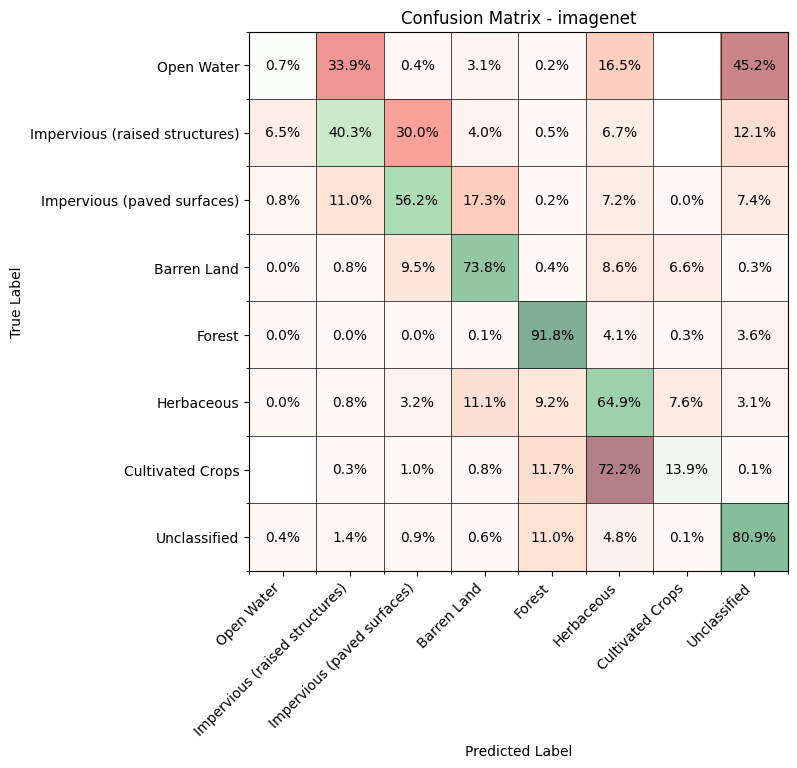

Evaluating model weights:  hsv_simclr
Preparing data
Training XGBoost model
Evaluating model
                                precision    recall  f1-score   support

                    Open Water       0.00      0.00      0.00       454
Impervious (raised structures)       0.51      0.45      0.48     16529
   Impervious (paved surfaces)       0.60      0.57      0.59     44589
                   Barren Land       0.65      0.83      0.73     74119
                        Forest       0.94      0.92      0.93    507047
                    Herbaceous       0.82      0.67      0.73    236196
              Cultivated Crops       0.00      0.02      0.01      4228
                  Unclassified       0.51      0.78      0.62     41065

                      accuracy                           0.81    924227
                     macro avg       0.50      0.53      0.51    924227
                  weighted avg       0.84      0.81      0.82    924227

['Open Water', 'Impervious (raised struc

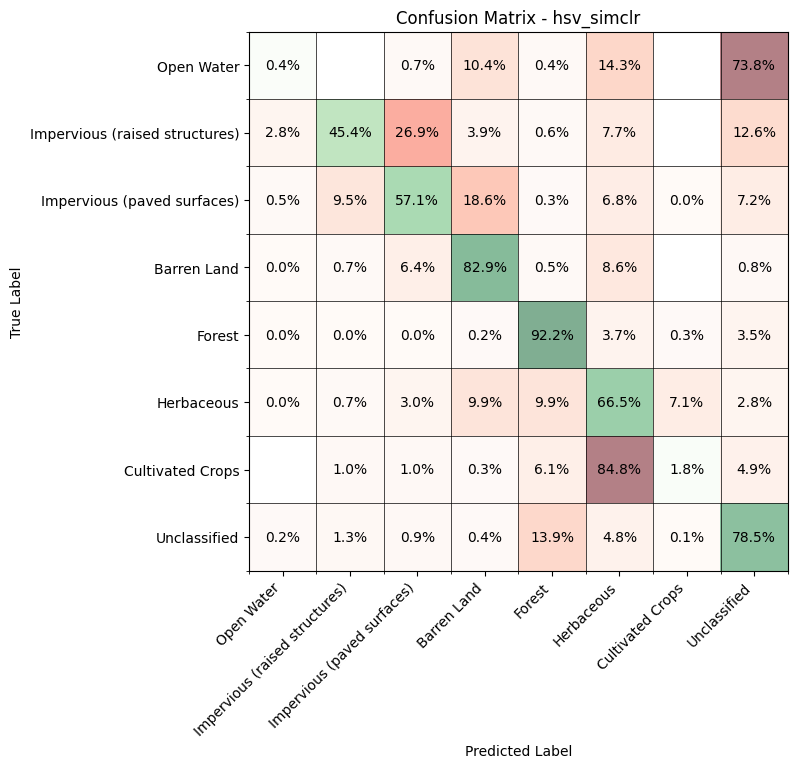

Evaluating model weights:  none
Preparing data
Training XGBoost model
Evaluating model
                                precision    recall  f1-score   support

                    Open Water       0.01      0.03      0.01       454
Impervious (raised structures)       0.24      0.58      0.34     16529
   Impervious (paved surfaces)       0.60      0.57      0.58     44589
                   Barren Land       0.63      0.78      0.69     74119
                        Forest       0.95      0.67      0.79    507047
                    Herbaceous       0.79      0.63      0.70    236196
              Cultivated Crops       0.04      0.58      0.07      4228
                  Unclassified       0.27      0.88      0.42     41065

                      accuracy                           0.67    924227
                     macro avg       0.44      0.59      0.45    924227
                  weighted avg       0.82      0.67      0.72    924227

['Open Water', 'Impervious (raised structures)

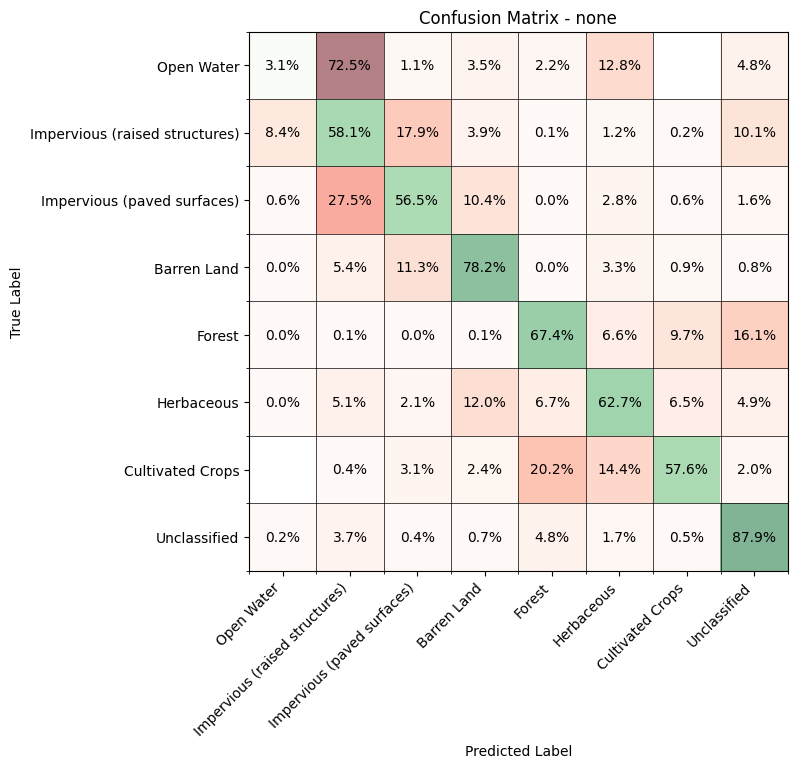

In [8]:
train_df, test_df = train_test_split(img_paths_df, test_size=0.3, random_state=1701)

print(f'Train images: {len(train_df)}')
print(f'Test images: {len(test_df)}')

offset = (256 - 192) // 2 # only keep the center 192x192 pixels due to edge effects

y_train = np.stack(train_df['y'].values)[:, :, offset:-offset, offset:-offset].flatten()
y_test = np.stack(test_df['y'].values)[:, :, offset:-offset, offset:-offset].flatten()
y_preds = {}

zero_indices_train = (y_train == 0)
zero_indices_test = (y_test == 0)

y_train = y_train[~zero_indices_train] - 1
y_test = y_test[~zero_indices_test] - 1

print(f'Train size: {y_train.shape[0]}')
print(f'Test size: {y_test.shape[0]}')

probs = np.bincount(y_train) / len(y_train)
sample_weights = compute_sample_weight('balanced', y=y_train)
for i in range(len(probs)):
    print(f'Class {LEGEND_CLASSES[i+1]} - probability: {probs[i]}')

for model in ['imagenet', 'hsv_simclr', 'none']:
    print("Evaluating model weights: ", model)
    
    print('Preparing data')
    
    if model == 'none':
        X_train = np.stack(train_df[f'aggregated_features_imagenet'])[:, :, offset:-offset, offset:-offset].transpose(0, 2, 3, 1).reshape(-1, n_features)[:, -6:]
        X_test = np.stack(test_df[f'aggregated_features_imagenet'])[:, :, offset:-offset, offset:-offset].transpose(0, 2, 3, 1).reshape(-1, n_features)[:, -6:]

    else:
        X_train = np.stack(train_df[f'aggregated_features_{model}'])[:, :, offset:-offset, offset:-offset].transpose(0, 2, 3, 1).reshape(-1, n_features)
        X_test = np.stack(test_df[f'aggregated_features_{model}'])[:, :, offset:-offset, offset:-offset].transpose(0, 2, 3, 1).reshape(-1, n_features)
    
    X_train = X_train[~zero_indices_train] - 1
    X_test = X_test[~zero_indices_test] - 1
    
    print('Training XGBoost model')
    
    xgb = XGBClassifier(n_estimators=100, n_jobs=-1, random_state=1701)
    xgb.fit(X_train, y_train, sample_weight=sample_weights)
    
    print('Evaluating model')
    y_pred = xgb.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=list(LEGEND_CLASSES.values())[1:]))
    y_preds[model] = y_pred
    
    plot_confusion_matrix(y_test, y_pred, labels=list(LEGEND_CLASSES.values())[1:], title=f'Confusion Matrix - {model}')


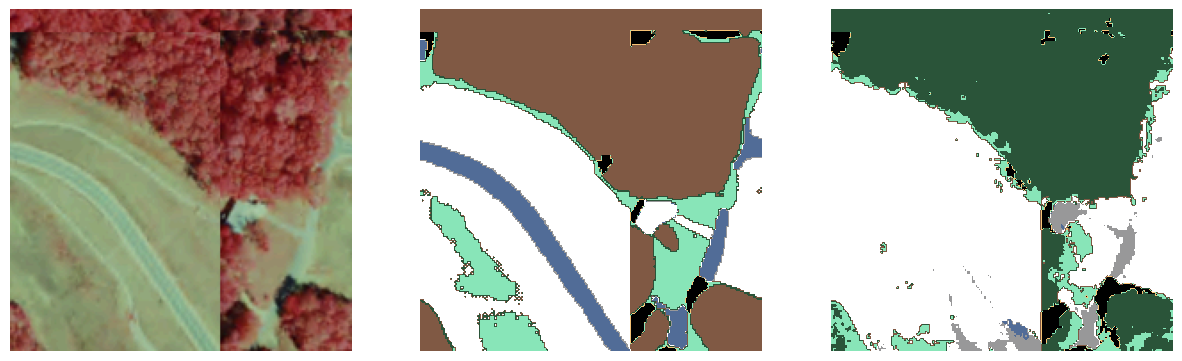

In [107]:
sample_idx = 2
array_sample_slice = slice(sample_idx * (192 ** 2), (sample_idx + 1) * (192 ** 2))
fig, ax = plt.subplots(1, 3, figsize=(15, 15))

# x_sample = test_df.iloc[sample_idx]['X'][:, offset:-offset, offset:-offset].transpose(1, 2, 0)
# y_true_sample = test_df.iloc[sample_idx]['y'][:, offset:-offset, offset:-offset].squeeze()
# y_pred_sample = y_preds['imagenet'][array_sample_slice].reshape(192, 192).squeeze()

# x_sample = X_test[array_sample_slice].reshape(6, 192, 192).transpose(1, 2, 0)[:, :, 2]
x_sample = ((X_test[array_sample_slice, -3:].reshape(192, 192, 3) + dataset_mean) * dataset_std).astype(int)
x_sample = (x_sample - x_sample.min()) / (x_sample.max() + x_sample.min())
y_true_sample = y_test[array_sample_slice].reshape(192, 192).squeeze()
y_pred_sample = y_preds['hsv_simclr'][array_sample_slice].reshape(192, 192).squeeze()

cmap = mcolors.ListedColormap(list(LEGEND_COLORS_HEX.values()))

ax[0].imshow(x_sample)
ax[1].imshow(y_true_sample, cmap=cmap)
ax[2].imshow(y_pred_sample, cmap=cmap)

for i in range(3):
    ax[i].axis('off')

In [10]:
list(y_preds.keys())

['imagenet', 'hsv_simclr', 'none']